# 08 Pipeline

This notebook captures the current draft end-to-end single-nucleus RNA-seq workflow for the C9 multiomics project. The main path below is arranged to be runnable in a clean order. Exploratory, superseded, or debugging cells are preserved in an appendix at the end for review.


## Imports And Package Setup


In [124]:
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [89]:
import sys
sys.path.append(str(Path("../src").resolve()))
from c9_snrnaseq.io_utils import PROJECT_ROOT, load_and_annotate_sheet, save_checkpoint, _stage_header, _log
from c9_snrnaseq.qc_low_quality_cell import (
    compute_qc_metrics,
    detect_low_quality_cells,
    remove_low_quality_cells,
    freeze_raw_counts,
)
from c9_snrnaseq.ambient_rna import (
    estimate_ambient_rna,
    remove_ambient_rna,
)
from c9_snrnaseq.doublets_removal import (
    detect_doublets,
    remove_doublets,
)

from c9_snrnaseq.expression_preprocessing import (
    normalize_counts,
    log_transform,
    select_hvgs,
    scale_expression
)

from c9_snrnaseq.dimensionality_reduction import (
    run_pca,
    build_neighbor_graph,
    run_umap
)

from c9_snrnaseq.annotation import (
    run_leiden_clustering,
    find_cluster_markers
)


In [127]:
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
PSEUDOBULK_DIR = RESULTS_DIR / "pseudobulk"
PSEUDOBULK_EXC_DIR = RESULTS_DIR / "pseudobulk_exc_focus"
DE_BROAD_DIR = RESULTS_DIR / "de_pseudobulk_broad"
DE_EXC_DIR = RESULTS_DIR / "de_pseudobulk_exc_focus"

for d in [
    FIGURES_DIR,
    TABLES_DIR,
    PSEUDOBULK_DIR,
    PSEUDOBULK_EXC_DIR,
    DE_BROAD_DIR,
    DE_EXC_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

## Pipeline Function Definitions

These functions define the sample-level preprocessing pipeline, the full merged pipeline, and a checkpoint-resume version that rebuilds the merged object from saved `*_after_doublet_removal.h5ad` files.


In [90]:
def process_one_sample(
    sample_row: pd.Series,
    processed_dir: str | Path = "../data/processed/per_sample",
    save_intermediate: bool = True,
    verbose: bool = True
) -> dict:
    """
    Process one sample through sample-level low-quality-cell filtering, ambient RNA correction, and doublet detection / removal.
    Workflow:
        1. Load filtered count matrix and annotate metadata.
        2. Compute QC metrics.
        3. Detect low-quality cells.
        4. Save checkpoint before removing the low-quality cells.
        5. Remove low-quality cells.
        6. Freeze raw counts.
        7. Save checkpoint after removing the low-quality cells.
        8. Load matching raw droplet matrix.
        9. Estimate and remove ambient RNA.
        10. Save checkpoint after ambient RNA correction.
        11. Detect doublets.
        12. Save checkpoint before doublet removal.
        13. Remove doublets.
        14. Save checkpoint after doublet removal.
    -----------
    Parameters
    -----------
        sample_row: One row from the sample sheet (pandas Series). Must contain:
            - sample_id
            - condition 
            - filtered_matrix_dir
            - raw_matrix_dir
            Optional fileds such as dataset will be added to 'adata.obs' by load_and_annotate_sheet() if present.
        processed_dir: Base directory where per-sample checkpoint '.h5ad' files will be saved. 
        save_intermediate: Whether to save checkpoint files after key stages.
        verbose: Whether to print concise stage-level progress messages.
    --------
    Returns
    --------
        result: a dictionary object containing
            - "sample_id": sample_identifier 
            - "adata_postQC": final adata object after the three stages of cleaning.
            - "sc_chan": SoupX channel object
            - "scrub": Scrublet object
            - "checkpoint_paths": dict of saved checkpoint paths
    """
    total_stages = 5

    sample_id = str(sample_row["sample_id"])
    condition = str(sample_row['condition'])
    processed_dir = Path(processed_dir)
    if not processed_dir.is_absolute():
        processed_dir = PROJECT_ROOT / processed_dir
    sample_outdir = processed_dir / sample_id
    sample_outdir.mkdir(parents=True, exist_ok=True)

    checkpoint_paths: dict[str, Path] = {}

    _log(f"\nProcessing sample: {sample_id} ({condition})", verbose)

    # Load filtered count matrix.
    _stage_header(1, total_stages, "Load sample", verbose)
    adata = load_and_annotate_sheet(sample_row)
    _log(f"Loaded sample {sample_id}: {adata.n_obs} cells x {adata.n_vars} genes", verbose)
    # Compute QC metrics
    _stage_header(2, total_stages, "Low-quality-cell filtering", verbose)
    adata = compute_qc_metrics(adata)
    # Detect + Remove low-quality cells
    adata = detect_low_quality_cells(adata)
    if save_intermediate:
        checkpoint_paths["before_low_quality_cell_filtering"] = save_checkpoint(
            adata = adata,
            output_dir = sample_outdir,
            stage_name = "before_low_quality_cell_filtering" 
        )
    adata = remove_low_quality_cells(adata)
    _log(f"Low-quality-cell filtering complete: ", verbose,)

    # Freeze raw counts
    _stage_header(3, total_stages, "Freeze raw counts and save checkpoint", verbose)
    adata = freeze_raw_counts(adata)
    if save_intermediate:
        checkpoint_paths["after_low_quality_cell_filtering"] = save_checkpoint(
            adata = adata,
            output_dir = sample_outdir,
            stage_name = "after_low_quality_cell_filtering",
        )
    _log("Raw counts frozen and post-filter checkpoint saved.", verbose)

    # Load raw droplet matrix
    _stage_header(4, total_stages, "Ambient RNA correction", verbose)
    raw_dir = Path(sample_row["raw_matrix_dir"])
    if not raw_dir.is_absolute():
        raw_dir = PROJECT_ROOT / raw_dir
    if not raw_dir.exists():
        raise FileNotFoundError(f"Raw matrix directory not found: {raw_dir}")
    adata_raw = sc.read_10x_mtx(
        raw_dir,
        var_names = "gene_symbols",
        cache = False
    )
    adata_raw.var_names_make_unique()

    # Estimate + Remove ambient RNA
    adata, sc_chan = estimate_ambient_rna(
        adata = adata,
        adata_raw = adata_raw
    )
    adata = remove_ambient_rna(
        adata = adata,
        sc_chan = sc_chan
    )
    if save_intermediate:
        checkpoint_paths["after_ambient_rna_removal"] = save_checkpoint(
            adata = adata,
            output_dir = sample_outdir,
            stage_name = "after_ambient_rna_removal"
        )
    _log("Ambient RNA correction complete.", verbose)

    # Detect + Remove doublets
    _stage_header(5, total_stages, "Doublet detection and removal", verbose)
    adata, scrub = detect_doublets(adata)
    if save_intermediate:
        checkpoint_paths["before_doublet_removal"] = save_checkpoint(
            adata = adata,
            output_dir = sample_outdir,
            stage_name = "before_doublet_removal",
        )
    adata = remove_doublets(adata)
    if save_intermediate:
        checkpoint_paths["after_doublet_removal"] = save_checkpoint(
            adata = adata,
            output_dir = sample_outdir,
            stage_name = "after_doublet_removal"
        )
    _log(f"Doublet removal complete.", verbose)
    
    _log("\nAvailable checkpoint objects for before/after inspection:", verbose)
    for key, path in checkpoint_paths.items():
        _log(f"  {key} -> {path}", verbose)

    _log(f"\nFinished processing sample: {sample_id}\n", verbose)
    
    return {
        "sample_id": sample_id,
        "adata_postQC": adata,
        "sc_chan": sc_chan,
        "scrub": scrub, 
        "checkpoint_paths": checkpoint_paths
    }


In [ ]:
def process_all_samples(
        sample_sheet: str | Path = "config/samples.csv",
        processed_dir: str | Path = "data/processed/per_sample",
        merged_output_path: str | Path = "data/processed/merged/merged_after_clustering.h5ad",
        save_intermediate: bool = True,
        verbose: bool = True
) -> dict:
    """
    Process all samples listed in the sample sheet and save merged output.
    -----------
    Parameters
    -----------
        sample_sheet: Path to the sample sheet CSV file. Must contain columns:
            - sample_id
            - condition 
            - filtered_matrix_dir
            - raw_matrix_dir
        processed_dir: Base directory where per-sample checkpoint '.h5ad' files will be saved. 
        merged_output_path: Path where the merged adata object after processing all samples will be saved.
        save_intermediate: Whether to save checkpoint files after key stages for each sample.
        verbose: Whether to print concise stage-level progress messages.
    --------
    Returns
    --------
        result: a dictionary object containing
            - "per_sample_results": list of per-sample result dictionaries from process_one_sample()
            - "adata_merged": merged adata object after preprocessing, clustering, and marker detection
    """
    
    sample_sheet = Path(sample_sheet)
    if not sample_sheet.is_absolute():
        sample_sheet = PROJECT_ROOT / sample_sheet
    sample_df = pd.read_csv(sample_sheet)
    per_sample_results = []
    cleaned_adatas = []
    cleaned_paths = []

    for _, sample_row in sample_df.iterrows():
        result = process_one_sample(
            sample_row = sample_row,
            processed_dir = processed_dir,
            save_intermediate = save_intermediate,
            verbose = verbose
        )
        per_sample_results.append(result)
        cleaned_adatas.append(result["adata_postQC"])
        
        checkpoint_path = result["checkpoint_paths"].get("after_doublet_removal")
        if checkpoint_path is not None:
            cleaned_paths.append(checkpoint_path)
    
    adata_merged = sc.concat(
        cleaned_adatas,
        join="outer",
        label="concat_sample_id",
        keys=[adata.obs["sample"].iloc[0] for adata in cleaned_adatas],
        merge="same",
    )
    adata_merged.obs_names_make_unique()

    adata_merged = normalize_counts(adata_merged)
    adata_merged = log_transform(adata_merged)
    adata_merged = select_hvgs(adata_merged)
    adata_merged = scale_expression(adata_merged)
    adata_merged = run_pca(adata_merged)
    adata_merged = build_neighbor_graph(adata_merged)
    adata_merged = run_umap(adata_merged)
    adata_merged = run_leiden_clustering(adata_merged)
    adata_merged = find_cluster_markers(adata_merged)

    merged_output_path = Path(merged_output_path)
    if not merged_output_path.is_absolute():
        merged_output_path = PROJECT_ROOT / merged_output_path
    merged_output_path.parent.mkdir(parents=True, exist_ok=True)
    adata_merged.write_h5ad(merged_output_path)
    _log(f"Merged dataset saved to: {merged_output_path}", verbose)

    return {
        "sample_table": sample_df,
        "per_sample_results": per_sample_results,
        "cleaned_paths": cleaned_paths,
        "adata_merged": adata_merged,
        "merged_output_path": merged_output_path,
    }


In [92]:
def process_all_samples_truncated(
    sample_sheet: str | Path = "config/samples.csv",
    processed_dir: str | Path = "data/processed/per_sample",
    merged_output_path: str | Path = "data/processed/merged/merged_after_clustering.h5ad",
    verbose: bool = True,
) -> dict:

    sample_sheet = Path(sample_sheet)
    if not sample_sheet.is_absolute():
        sample_sheet = PROJECT_ROOT / sample_sheet

    processed_dir = Path(processed_dir)
    if not processed_dir.is_absolute():
        processed_dir = PROJECT_ROOT / processed_dir

    merged_output_path = Path(merged_output_path)
    if not merged_output_path.is_absolute():
        merged_output_path = PROJECT_ROOT / merged_output_path

    sample_df = pd.read_csv(sample_sheet)
    cleaned_adatas = []
    cleaned_paths = []

    for _, sample_row in sample_df.iterrows():
        sample_id = str(sample_row["sample_id"])
        sample_dir = processed_dir / sample_id

        matches = sorted(sample_dir.glob("*_after_doublet_removal.h5ad"))
        if not matches:
            raise FileNotFoundError(
                f"No final cleaned checkpoint found for {sample_id} in {sample_dir}"
            )
        if len(matches) > 1:
            raise FileExistsError(
                f"Multiple final cleaned checkpoints found for {sample_id}: {matches}"
            )

        cleaned_path = matches[0]
        cleaned_paths.append(cleaned_path)
        cleaned_adatas.append(sc.read_h5ad(cleaned_path))

    adata_merged = sc.concat(
        cleaned_adatas,
        join="outer",
        label="concat_sample_id",
        keys=[adata.obs["sample"].iloc[0] for adata in cleaned_adatas],
        merge="same",
    )
    adata_merged.obs_names_make_unique()

    adata_merged = normalize_counts(adata_merged)
    adata_merged = log_transform(adata_merged)
    adata_merged = select_hvgs(adata_merged)
    adata_merged = scale_expression(adata_merged)
    adata_merged = run_pca(adata_merged)
    adata_merged = build_neighbor_graph(adata_merged)
    adata_merged = run_umap(adata_merged)
    adata_merged = run_leiden_clustering(adata_merged)
    adata_merged = find_cluster_markers(adata_merged)

    merged_output_path.parent.mkdir(parents=True, exist_ok=True)
    adata_merged.write_h5ad(merged_output_path)

    return {
        "sample_table": sample_df,
        "cleaned_paths": cleaned_paths,
        "adata_merged": adata_merged,
        "merged_output_path": merged_output_path,
    }

## Input Metadata


In [93]:
sample_sheet = Path("../config/samples.csv")
samples = pd.read_csv(sample_sheet)
display(samples)

,sample_id,condition,dataset,tissue,source_name,filtered_matrix_dir,raw_matrix_dir
0,GSM5292174,Control,GSE174332,Motor Cortex,Motor Cortex,results/40_starsolo_count/GSM5292174_PN/Solo.o...,results/40_starsolo_count/GSM5292174_PN/Solo.o...
1,GSM5292175,Control,GSE174332,Motor Cortex,Motor Cortex,results/41_starsolo_count/GSM5292175_PN/Solo.o...,results/41_starsolo_count/GSM5292175_PN/Solo.o...
2,GSM5292176,Control,GSE174332,Motor Cortex,Motor Cortex,results/42_starsolo_count/GSM5292176_PN/Solo.o...,results/42_starsolo_count/GSM5292176_PN/Solo.o...
3,GSM5292177,Control,GSE174332,Motor Cortex,Motor Cortex,results/42_starsolo_count/GSM5292177_PN/Solo.o...,results/42_starsolo_count/GSM5292177_PN/Solo.o...
4,GSM5292146,c9ALS,GSE174332,Motor Cortex,Motor Cortex,results/40_starsolo_count/GSM5292146_c9ALS/Sol...,results/40_starsolo_count/GSM5292146_c9ALS/Sol...
5,GSM5292147,c9ALS,GSE174332,Motor Cortex,Motor Cortex,results/41_starsolo_count/GSM5292147_c9ALS/Sol...,results/41_starsolo_count/GSM5292147_c9ALS/Sol...
6,GSM5292156,c9ALS,GSE174332,Motor Cortex,Motor Cortex,results/42_starsolo_count/GSM5292156_c9ALS/Sol...,results/42_starsolo_count/GSM5292156_c9ALS/Sol...
7,GSM5292157,c9ALS,GSE174332,Motor Cortex,Motor Cortex,results/42_starsolo_count/GSM5292157_c9ALS/Sol...,results/42_starsolo_count/GSM5292157_c9ALS/Sol...
8,GSM5292143,sALS,GSE174332,Motor Cortex,Motor Cortex,results/41_starsolo_count/GSM5292143_sALS/Solo...,results/41_starsolo_count/GSM5292143_sALS/Solo...
9,GSM5292144,sALS,GSE174332,Motor Cortex,Motor Cortex,results/42_starsolo_count/GSM5292144_sALS/Solo...,results/42_starsolo_count/GSM5292144_sALS/Solo...


## Resume Merged Analysis From Saved Checkpoints

Use the truncated function to avoid repeating successful sample-level preprocessing.


In [ ]:
result = process_all_samples_truncated(
    sample_sheet="config/samples.csv",
    processed_dir="data/processed/per_sample",
    merged_output_path="data/processed/merged/merged_after_clustering.h5ad",
    verbose=True,
)

In [ ]:
adata_merged = result["adata_merged"]
sc.pl.umap(adata_merged, color="leiden")
sc.pl.umap(adata_merged, color="sample")
sc.pl.umap(adata_merged, color="condition")
sc.pl.umap(adata_merged, color=["sample", "condition", "leiden"])

## Harmony Integration And Broad Cell-Class Annotation


In [ ]:
import harmonypy as hm

adata_hm = adata_merged.copy()

# Harmony on existing PCA
X = adata_hm.obsm["X_pca"].astype("float64")
ho = hm.run_harmony(X, adata_hm.obs, vars_use="sample")

Z = ho.Z_corr
if Z.shape != X.shape:
    Z = Z.T

adata_hm.obsm["X_pca_harmony"] = Z

# Build graph and embedding from Harmony PCs
sc.pp.neighbors(adata_hm, use_rep="X_pca_harmony")
sc.tl.umap(adata_hm, random_state=0)
sc.tl.leiden(adata_hm, resolution=0.6, key_added="leiden_harmony")

# Plot
sc.pl.umap(adata_hm, color=["sample", "condition", "leiden_harmony"], wspace=0.35)

In [94]:
adata_hm.obs["leiden_harmony"].value_counts().sort_index()

leiden_harmony
0     25375
1     15427
2      7579
3      5293
4      5199
5      4314
6      4297
7      3353
8      2493
9      2245
10     1927
11     1888
12     1756
13     1616
14     1538
15     1434
16     1174
17      978
18      460
19      440
20      368
21      271
22      208
23      186
Name: count, dtype: int64

In [ ]:
marker_dict_broad = {
    "Excitatory_neurons": ["RORB", "THEMIS", "CUX2", "TLE4", "EYA4", "SCN4B", "NEFH"],
    "Inhibitory_neurons": ["GAD1", "GAD2", "PVALB", "SST", "VIP", "RELN", "LAMP5"],

    "Astrocytes": ["GFAP", "AQP4", "SLC1A2", "SLC1A3", "ATP1A2", "CD44"],
    "Microglia": ["P2RY12", "TYROBP", "LST1", "AIF1", "C1QC", "FCER1G"],
    "OPCs": ["PTPRZ1", "VCAN", "TNR", "PDGFRA", "CSPG4"],
    "Oligodendrocytes": ["CNP", "PLP1", "MBP", "MOBP", "SLC44A1", "TF", "ABCA2"],

    "Endothelial": ["CLDN5", "PECAM1", "FLT1", "VWF", "ABCB1"],
    "Vascular_mural_like": ["PDGFRB", "RGS5", "MCAM", "CALD1", "ACTA2", "TAGLN", "MYH11"]
}

marker_dict_broad_present = {
    celltype: [g for g in genes if g in adata_hm.var_names]
    for celltype, genes in marker_dict_broad.items()
}
marker_dict_broad_present = {
    celltype: genes
    for celltype, genes in marker_dict_broad_present.items()
    if len(genes) > 0
}

marker_dict_broad_present

In [ ]:
sc.pl.dotplot(
    adata_hm,
    marker_dict_broad_present,
    groupby="leiden_harmony",
    standard_scale="var"
)

In [ ]:
umap_marker_panel = [g for g in [
    "GFAP", "AQP4",
    "GAD1", "GAD2",
    "P2RY12", "TYROBP", "C1QC",
    "PTPRZ1", "VCAN",
    "CLDN5", "PECAM1",
    "PDGFRB", "RGS5",
    "RORB", "THEMIS", "EYA4"
] if g in adata_hm.var_names]

sc.pl.umap(adata_hm, color=umap_marker_panel, ncols=3)

In [ ]:
# Update the annotation
cluster_to_major_harmony = {
    "0": "Unknown",
    "1": "Unknown",
    "2": "Excitatory_neurons",
    "3": "Excitatory_neurons",
    "4": "Astrocytes",
    "5": "OPCs",
    "6": "Microglia",
    "7": "Microglia",
    "8": "Inhibitory_neurons",
    "9": "Excitatory_neurons",
    "10": "Inhibitory_neurons",
    "11": "Excitatory_neurons",
    "12": "Excitatory_neurons",
    "13": "Astrocytes",
    "14": "Excitatory_neurons",
    "15": "Inhibitory_neurons",
    "16": "Unknown",
    "17": "Inhibitory_neurons",
    "18": "Excitatory_neurons",
    "19": "Excitatory_neurons",
    "20": "Endothelial",
    "21": "Vascular_mural_like",
    "22": "Excitatory_neurons",
    "23": "Astrocytes",
}

adata_hm.obs["cell_class_major_harmony"] = adata_hm.obs["leiden_harmony"].map(cluster_to_major_harmony)
adata_hm.obs["cell_class_major_harmony"] = adata_hm.obs["cell_class_major_harmony"].astype("category")

In [ ]:
sc.pl.umap(
    adata_hm,
    color=["cell_class_major_harmony", "sample", "condition"],
    wspace=0.35
)

In [ ]:
pd.crosstab(adata_hm.obs["cell_class_major_harmony"], adata_hm.obs["condition"])

In [ ]:
pd.crosstab(adata_hm.obs["cell_class_major_harmony"], adata_hm.obs["sample"])

## Refine Ambiguous Harmony Clusters

This section inspects initially ambiguous Harmony clusters and then creates both a refined label set and a collapsed broad label set for downstream work.


In [ ]:
unknown_refine_markers = {
    "Neuronal_exc_like": ["RORB", "THEMIS", "EYA4", "NEFH", "SCN4B", "CUX2", "TLE4", "SYT1", "CLSTN2", "CNTN4"],
    "Neuronal_inh_like": ["GAD1", "GAD2", "SST", "VIP", "RELN", "PVALB", "LAMP5"],
    "Astro_like": ["GFAP", "AQP4", "SLC1A2", "SLC1A3", "ATP1A2", "CD44"],
    "Microglia_like": ["P2RY12", "TYROBP", "LST1", "AIF1", "C1QC", "FCER1G", "SPP1"],
    "OPC_like": ["PTPRZ1", "VCAN", "TNR", "PDGFRA", "CSPG4"],
    "Vascular_like": ["CLDN5", "PECAM1", "FLT1", "VWF", "PDGFRB", "RGS5", "ACTA2"],
    "Stress_IEG": ["FOS", "EGR1", "HSPA1A", "HSPH1", "DNAJA4", "NR4A1"]
}
unknown_refine_markers = {
    k: [g for g in v if g in adata_hm.var_names]
    for k, v in unknown_refine_markers.items()
}
unknown_refine_markers = {k: v for k, v in unknown_refine_markers.items() if len(v) > 0}

unknown_clusters = ["0", "1", "16"]
sc.pl.dotplot(
    adata_hm[adata_hm.obs["leiden_harmony"].isin(unknown_clusters)].copy(),
    unknown_refine_markers,
    groupby="leiden_harmony",
    standard_scale="var"
)

In [ ]:
# Updated annotation
cluster_to_refined_harmony = {
    "0": "Unknown_neuronal_like",
    "1": "Microglia_reactive_like",
    "2": "Excitatory_neurons",
    "3": "Excitatory_neurons",
    "4": "Astrocytes",
    "5": "OPCs",
    "6": "Microglia",
    "7": "Microglia",
    "8": "Inhibitory_neurons",
    "9": "Excitatory_neurons",
    "10": "Inhibitory_neurons",
    "11": "Excitatory_neurons",
    "12": "Excitatory_neurons",
    "13": "Astrocytes",
    "14": "Excitatory_neurons",
    "15": "Inhibitory_neurons",
    "16": "Stress_IEG",
    "17": "Inhibitory_neurons",
    "18": "Excitatory_neurons",
    "19": "Excitatory_neurons",
    "20": "Endothelial",
    "21": "Vascular_mural_like",
    "22": "Excitatory_neurons",
    "23": "Astrocytes",
}

adata_hm.obs["cell_class_refined_harmony"] = (
    adata_hm.obs["leiden_harmony"].astype(str).map(cluster_to_refined_harmony)
)

adata_hm.obs["cell_class_refined_harmony"] = (
    adata_hm.obs["cell_class_refined_harmony"].astype("category")
)

# collapse to broad classes for downstream analysis
collapse_to_broad = {
    "Unknown_neuronal_like": "Unknown",
    "Microglia_reactive_like": "Microglia",
    "Stress_IEG": "Unknown",
}

adata_hm.obs["cell_class_major_harmony"] = (
    adata_hm.obs["cell_class_refined_harmony"]
    .astype(str)
    .replace(collapse_to_broad)
    .astype("category")
)

sc.pl.umap(
    adata_hm,
    color=["cell_class_refined_harmony", "cell_class_major_harmony", "sample", "condition"],
    wspace=0.35
)

In [ ]:
pd.crosstab(adata_hm.obs["cell_class_refined_harmony"], adata_hm.obs["condition"])

## Rebuild A Raw-Count Merged Object For Pseudobulk


In [ ]:
sample_df = pd.read_csv(PROJECT_ROOT / "config/samples.csv")

cleaned_adatas = []

for _, row in sample_df.iterrows():
    sample_id = str(row["sample_id"])
    sample_dir = PROJECT_ROOT / "data/processed/per_sample" / sample_id
    matches = sorted(sample_dir.glob("*_after_doublet_removal.h5ad"))

    if not matches:
        raise FileNotFoundError(f"No after_doublet_removal checkpoint found for {sample_id}")
    if len(matches) > 1:
        raise FileExistsError(f"Multiple after_doublet_removal checkpoints found for {sample_id}: {matches}")

    ad = sc.read_h5ad(matches[0])

    # overwrite / enforce metadata from samples.csv
    ad.obs["sample"] = sample_id
    ad.obs["condition"] = row["condition"]
    ad.obs["dataset"] = row["dataset"]
    ad.obs["tissue"] = row["tissue"]
    ad.obs["source_name"] = row["source_name"]

    # preserve original barcode and create unique merge key
    ad.obs["barcode"] = ad.obs_names.astype(str)
    ad.obs["merge_key"] = ad.obs["sample"].astype(str) + "__" + ad.obs["barcode"].astype(str)
    ad.obs_names = ad.obs["merge_key"].values

    cleaned_adatas.append(ad)

adata_merged_pb = sc.concat(
    cleaned_adatas,
    join="outer",
    merge="same",
    fill_value=0
)

adata_merged_pb.obs_names_make_unique()

# standardise raw counts storage
if "raw_counts" in adata_merged_pb.layers:
    adata_merged_pb.layers["counts"] = adata_merged_pb.layers["raw_counts"].copy()
else:
    adata_merged_pb.layers["counts"] = adata_merged_pb.X.copy()

print(adata_merged_pb.shape)
print("X dtype:", adata_merged_pb.X.dtype)
print("counts layer exists:", "counts" in adata_merged_pb.layers)
print("samples:", sorted(adata_merged_pb.obs["sample"].astype(str).unique()))

In [ ]:
adata_hm.obs["barcode"] = adata_hm.obs_names.astype(str)
adata_hm.obs["merge_key"] = adata_hm.obs["sample"].astype(str) + "__" + adata_hm.obs["barcode"].astype(str)

refined_map = adata_hm.obs.set_index("merge_key")["cell_class_refined_harmony"].to_dict()
major_map = adata_hm.obs.set_index("merge_key")["cell_class_major_harmony"].to_dict()

adata_merged_pb.obs["cell_class_refined_harmony"] = adata_merged_pb.obs["merge_key"].map(refined_map)
adata_merged_pb.obs["cell_class_major_harmony"] = adata_merged_pb.obs["merge_key"].map(major_map)

print(adata_merged_pb.obs["cell_class_major_harmony"].value_counts(dropna=False))

In [ ]:
print("Cells in pb object:", adata_merged_pb.n_obs)
print("Cells with transferred major label:", adata_merged_pb.obs["cell_class_major_harmony"].notna().sum())
print("Cells missing transferred major label:", adata_merged_pb.obs["cell_class_major_harmony"].isna().sum())

In [ ]:
confident_classes = [
    "Excitatory_neurons",
    "Inhibitory_neurons",
    "Astrocytes",
    "Microglia",
    "OPCs",
    "Endothelial",
    "Vascular_mural_like",
]

adata_pb_conf = adata_merged_pb[
    adata_merged_pb.obs["cell_class_major_harmony"].isin(confident_classes)
].copy()

print(adata_pb_conf.obs["cell_class_major_harmony"].value_counts())

## Excitatory-Neuron Focused Refinement


In [ ]:
adata_exc = adata_hm[adata_hm.obs["cell_class_major_harmony"] == "Excitatory_neurons"].copy()
print(adata_exc.shape)
print(adata_exc.obs["leiden_harmony"].value_counts().sort_index())

In [ ]:
umn_marker_dict = {
    "VAT1L_UMN_like": ["VAT1L", "EYA4", "THSD4", "POU3F1", "NEFH", "SCN4B"],
    "SCN4B_projection_like": ["SCN4B", "NEFH", "SYT2", "SV2C"],
    "Broad_L5_exc": ["TLE4", "BCL11B", "FEZF2", "CRYM", "PCP4"],
    "Broad_IT_exc": ["CUX2", "RORB", "THEMIS", "SATB2"],
}

umn_marker_dict = {
    k: [g for g in v if g in adata_exc.var_names]
    for k, v in umn_marker_dict.items()
}
umn_marker_dict = {k: v for k, v in umn_marker_dict.items() if len(v) > 0}

umn_marker_dict

In [ ]:
sc.pl.dotplot(
    adata_exc,
    umn_marker_dict,
    groupby="leiden_harmony",
    standard_scale="var"
)

In [ ]:
umn_marker_panel = [g for g in [
    "VAT1L", "EYA4", "THSD4",
    "SCN4B", "NEFH",
    "TLE4", "BCL11B", "FEZF2", "CRYM", "PCP4",
    "RORB", "THEMIS", "CUX2", "SATB2"
] if g in adata_exc.var_names]

sc.pl.umap(adata_exc, color=umn_marker_panel, ncols=4)

In [ ]:
vat1l_program = [g for g in ["VAT1L", "EYA4", "THSD4", "POU3F1", "NEFH"] if g in adata_exc.var_names]
scn4b_program = [g for g in ["SCN4B", "NEFH", "SYT2", "SV2C"] if g in adata_exc.var_names]
deep_l5_program = [g for g in ["TLE4", "BCL11B", "FEZF2", "CRYM", "PCP4"] if g in adata_exc.var_names]

sc.tl.score_genes(adata_exc, gene_list=vat1l_program, score_name="VAT1L_program_score")
sc.tl.score_genes(adata_exc, gene_list=scn4b_program, score_name="SCN4B_program_score")

sc.pl.umap(
    adata_exc,
    color=["VAT1L_program_score", "SCN4B_program_score", "leiden_harmony"],
    ncols=2
)

In [ ]:
adata_exc.obs["exc_subclass_focus"] = "Other_excitatory"

# best UMN-like candidate
adata_exc.obs.loc[
    adata_exc.obs["leiden_harmony"].astype(str).isin(["22"]),
    "exc_subclass_focus"
] = "UMN_like_VAT1L"

# projection-like candidates
adata_exc.obs.loc[
    adata_exc.obs["leiden_harmony"].astype(str).isin(["11", "18"]),
    "exc_subclass_focus"
] = "Projection_like_SCN4B"

# broad IT-like excitatory
adata_exc.obs.loc[
    adata_exc.obs["leiden_harmony"].astype(str).isin(["12"]),
    "exc_subclass_focus"
] = "Broad_IT_exc"

adata_exc.obs["exc_subclass_focus"] = adata_exc.obs["exc_subclass_focus"].astype("category")

In [ ]:
sc.pl.umap(
    adata_exc,
    color=["exc_subclass_focus", "sample", "condition"],
    wspace=0.35
)

In [ ]:
print(pd.crosstab(adata_exc.obs["exc_subclass_focus"], adata_exc.obs["condition"]))

In [ ]:
print(pd.crosstab(adata_exc.obs["exc_subclass_focus"], adata_exc.obs["sample"]))

In [ ]:
if "merge_key" not in adata_exc.obs.columns:
    adata_exc.obs["barcode"] = adata_exc.obs_names.astype(str)
    adata_exc.obs["merge_key"] = adata_exc.obs["sample"].astype(str) + "__" + adata_exc.obs["barcode"].astype(str)

exc_focus_map = adata_exc.obs.set_index("merge_key")["exc_subclass_focus"].to_dict()

adata_merged_pb.obs["exc_subclass_focus"] = adata_merged_pb.obs["merge_key"].map(exc_focus_map)

print(adata_merged_pb.obs["exc_subclass_focus"].value_counts(dropna=False))

## Pseudobulk Setup And Differential Expression

The generalized pseudobulk helper below supports both broad major classes and excitatory-focused subclasses.


In [ ]:
broad_main_classes = [
    "Microglia",
    "Excitatory_neurons",
    "Astrocytes",
    "Inhibitory_neurons",
    "OPCs",
]

adata_pb_main = adata_merged_pb[
    adata_merged_pb.obs["cell_class_major_harmony"].isin(broad_main_classes)
].copy()

print(adata_pb_main.obs["cell_class_major_harmony"].value_counts())

In [ ]:
exc_focus_classes = [
    "UMN_like_VAT1L",
    "Projection_like_SCN4B",
    "Broad_IT_exc",
]

adata_pb_exc_focus = adata_merged_pb[
    adata_merged_pb.obs["exc_subclass_focus"].isin(exc_focus_classes)
].copy()

print(adata_pb_exc_focus.obs["exc_subclass_focus"].value_counts())

In [ ]:
print(pd.crosstab(adata_pb_exc_focus.obs["exc_subclass_focus"], adata_pb_exc_focus.obs["condition"]))

In [ ]:
print(pd.crosstab(adata_pb_exc_focus.obs["exc_subclass_focus"], adata_pb_exc_focus.obs["sample"]))

In [ ]:
exc_focus_de_classes = [
    "Projection_like_SCN4B",
    "Broad_IT_exc",
]

exc_focus_descriptive_classes = [
    "UMN_like_VAT1L",
]

In [ ]:
def pseudobulk_by_sample(
    adata,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts"
):
    sub = adata[adata.obs[groupby_col] == group_value].copy()

    cell_counts = sub.obs["sample"].value_counts()
    keep_samples = cell_counts[cell_counts >= min_cells_per_sample].index.tolist()
    sub = sub[sub.obs["sample"].isin(keep_samples)].copy()

    sample_order = sorted(sub.obs["sample"].unique())
    pb_counts = []
    pb_meta = []

    for samp in sample_order:
        ss = sub[sub.obs["sample"] == samp]
        x = ss.layers[layer]
        if hasattr(x, "toarray"):
            x = x.toarray()
        summed = np.asarray(x.sum(axis=0)).ravel()
        pb_counts.append(summed)

        pb_meta.append({
            "sample": samp,
            "condition": ss.obs["condition"].iloc[0],
            "group_value": group_value,
            "groupby_col": groupby_col,
            "n_cells": ss.n_obs
        })

    counts_df = pd.DataFrame(pb_counts, index=sample_order, columns=sub.var_names)
    meta_df = pd.DataFrame(pb_meta).set_index("sample")

    return counts_df, meta_df

In [ ]:
os.makedirs(PSEUDOBULK_EXC_DIR, exist_ok=True)

for ct in exc_focus_de_classes:
    counts_df, meta_df = pseudobulk_by_sample(
        adata_merged_pb,
        group_value=ct,
        groupby_col="exc_subclass_focus",
        min_cells_per_sample=20,
        layer="counts"
    )
    counts_df.to_csv(PSEUDOBULK_EXC_DIR / f"{ct}_counts.csv")
    meta_df.to_csv(PSEUDOBULK_EXC_DIR / f"{ct}_meta.csv")
    print(ct, counts_df.shape)
    print(meta_df)

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

def run_pairwise_deseq(counts_df, meta_df, group_a, group_b):
    keep = meta_df["condition"].isin([group_a, group_b])
    counts_use = counts_df.loc[keep].copy()
    meta_use = meta_df.loc[keep].copy()

    counts_use = counts_use.round().astype(int)

    dds = DeseqDataSet(
        counts=counts_use,
        metadata=meta_use,
        design_factors="condition",
        refit_cooks=True
    )
    dds.deseq2()

    stats = DeseqStats(dds, contrast=["condition", group_b, group_a])
    stats.summary()

    res = stats.results_df.copy()
    res["gene"] = res.index
    return res

In [ ]:
autophagy_genes = [
    # C9/autophagy core
    "C9orf72", "SMCR8", "WDR41",
    "ULK1", "ULK2", "RB1CC1", "ATG13", "ATG101",
    "BECN1", "PIK3C3", "ATG14", "WIPI2",
    "ATG5", "ATG7", "ATG12", "ATG16L1",
    "MAP1LC3B", "GABARAPL1", "GABARAPL2",
    "SQSTM1", "OPTN", "CALCOCO2", "TAX1BP1", "NBR1",
    "TBK1", "LAMP1", "LAMP2", "RAB7A", "CTSD",

    # canonical mitophagy
    "PINK1", "PRKN", "BNIP3", "BNIP3L", "FUNDC1",
    "PHB2", "BCL2L13", "FKBP8",

    # mitochondria dynamics: fission / fusion
    "DNM1L", "FIS1", "MFF", "MIEF1", "MIEF2",
    "MFN1", "MFN2", "OPA1",

    # mitochondrial transport / membrane / contact / turnover relevance
    "RHOT1", "RHOT2", "VDAC1", "TOMM20", "TOMM70",
    "TIMM23", "TIMM44",

    # mitochondrial proteostasis / UPRmt / stress response
    "LONP1", "CLPP", "CLPX", "AFG3L2", "SPG7",
    "HSPD1", "HSPE1", "DNAJA3",

    # mitochondrial biogenesis / transcriptional control
    "PPARGC1A", "PPARGC1B", "NRF1", "NRF2", "TFAM",
    "TFB1M", "TFB2M", "POLG", "POLG2",

    # respiration / mitochondrial function / homeostasis
    "NDUFS1", "NDUFV1", "SDHA", "UQCRC1", "COX4I1", "ATP5F1A",
    "SOD2", "PRDX3", "GPX4", "TXN2",

    # mitochondrial membrane potential / calcium / permeability transition
    "IMMT", "MICOS10", "MCU", "MICU1", "MICU2",
    "SLC25A4", "SLC25A5",

    # lysosome / acidification / autophagosome-lysosome axis
    "ATP6V1A", "ATP6V0C", "RAB9A", "UVRAG", "VPS11", "VPS16"
]

autophagy_present = [g for g in autophagy_genes if g in adata_pb_main.var_names]
print(autophagy_present)

adata_plot = adata_pb_main[:, autophagy_present].copy()
print(adata_plot.shape)

In [ ]:
pairwise_tests = [
    ("Control", "sALS"),
    ("Control", "c9ALS"),
    ("sALS", "c9ALS"),
]

os.makedirs(DE_BROAD_DIR, exist_ok=True)

broad_de_results = {}

for ct in broad_main_classes:
    counts_df, meta_df = pseudobulk_by_sample(
        adata_merged_pb,
        group_value=ct,
        groupby_col="cell_class_major_harmony",
        min_cells_per_sample=20,
        layer="counts"
    )

    print(f"\n=== {ct} ===")
    print(meta_df)

    for g1, g2 in pairwise_tests:
        res = run_pairwise_deseq(counts_df, meta_df, g1, g2)

        # save full results
        res.to_csv(DE_BROAD_DIR / f"{ct}_{g1}_vs_{g2}.csv", index=False)

        # save mito/autophagy-only results
        res_panel = res[res["gene"].isin(autophagy_genes)].copy()
        res_panel.to_csv(DE_BROAD_DIR / f"{ct}_{g1}_vs_{g2}_mito_qc.csv", index=False)

        broad_de_results[(ct, g1, g2)] = res_panel

In [ ]:
os.makedirs(DE_EXC_DIR, exist_ok=True)

exc_focus_de_results = {}

for ct in exc_focus_de_classes:
    counts_df, meta_df = pseudobulk_by_sample(
        adata_merged_pb,
        group_value=ct,
        groupby_col="exc_subclass_focus",
        min_cells_per_sample=20,
        layer="counts"
    )

    print(f"\n=== {ct} ===")
    print(meta_df)

    for g1, g2 in pairwise_tests:
        res = run_pairwise_deseq(counts_df, meta_df, g1, g2)

        # save full results
        res.to_csv(DE_EXC_DIR / f"{ct}_{g1}_vs_{g2}.csv", index=False)

        # save mito/autophagy-only results
        res_panel = res[res["gene"].isin(autophagy_genes)].copy()
        res_panel.to_csv(DE_EXC_DIR / f"{ct}_{g1}_vs_{g2}_mito_qc.csv", index=False)

        exc_focus_de_results[(ct, g1, g2)] = res_panel

## Summaries And Result Inspection


In [135]:
RESULT_DIRS = {
    "broad": Path(DE_BROAD_DIR),
    "exc_focus": Path(DE_EXC_DIR),
}

VALID_COMPARISONS = {
    "Control_vs_sALS",
    "Control_vs_c9ALS",
    "sALS_vs_c9ALS",
}

In [132]:
def load_de_result(
    analysis_level,
    group_name,
    comparison,
    result_dirs=RESULT_DIRS,
    suffix="_mito_qc.csv",
):
    if analysis_level not in result_dirs:
        raise ValueError(f"analysis_level must be one of {list(result_dirs)}")
    if comparison not in VALID_COMPARISONS:
        raise ValueError(f"comparison must be one of {sorted(VALID_COMPARISONS)}")

    fn = result_dirs[analysis_level] / f"{group_name}_{comparison}{suffix}"
    if not fn.exists():
        raise FileNotFoundError(f"Result file not found: {fn}")

    df = pd.read_csv(fn)
    df["analysis_level"] = analysis_level
    df["group_name"] = group_name
    df["comparison"] = comparison
    df["source_file"] = str(fn)
    return df

def load_de_results(
    analysis_level,
    group_names,
    comparisons,
    result_dirs=RESULT_DIRS,
    suffix="_mito_qc.csv",
):
    dfs = []
    for group_name in group_names:
        for comparison in comparisons:
            dfs.append(
                load_de_result(
                    analysis_level=analysis_level,
                    group_name=group_name,
                    comparison=comparison,
                    result_dirs=result_dirs,
                    suffix=suffix,
                )
            )
    return pd.concat(dfs, ignore_index=True)

def plot_volcano(
    analysis_level,
    group_name,
    comparison,
    genes_to_label=None,
    padj_cutoff=0.1,
    lfc_cutoff=0.5,
    result_dirs=RESULT_DIRS,
    suffix="_mito_qc.csv",
    figsize=(8, 6),
):
    df = load_de_result(
        analysis_level=analysis_level,
        group_name=group_name,
        comparison=comparison,
        result_dirs=result_dirs,
        suffix=suffix,
    ).copy()

    df = df.dropna(subset=["padj", "log2FoldChange"]).copy()
    df["neglog10_padj"] = -np.log10(df["padj"].clip(lower=1e-300))

    df["sig"] = "NS"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] > lfc_cutoff), "sig"] = "Up"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] < -lfc_cutoff), "sig"] = "Down"

    fig, ax = plt.subplots(figsize=figsize)
    colors = {"NS": "lightgray", "Up": "firebrick", "Down": "steelblue"}

    for label in ["NS", "Up", "Down"]:
        sub = df[df["sig"] == label]
        ax.scatter(
            sub["log2FoldChange"],
            sub["neglog10_padj"],
            s=28,
            alpha=0.8,
            color=colors[label],
            label=label,
        )

    if genes_to_label:
        label_df = df[df["gene"].isin(genes_to_label)].copy()
        for _, row in label_df.iterrows():
            ax.text(
                row["log2FoldChange"],
                row["neglog10_padj"],
                row["gene"],
                fontsize=8,
            )

    ax.axvline(lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axvline(-lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axhline(-np.log10(padj_cutoff), linestyle="--", color="black", linewidth=1)

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(f"{group_name} | {comparison}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return df

def plot_log2fc_heatmap(
    analysis_level,
    group_names,
    comparisons,
    genes=None,
    top_n_per_result=None,
    padj_cutoff=0.1,
    result_dirs=RESULT_DIRS,
    suffix="_mito_qc.csv",
    figsize_per_gene=0.28,
    min_fig_h=8,
    max_fig_h=28,
    ytick_fontsize=8,
):
    long_dfs = []
    selected_genes = set()

    for group_name in group_names:
        for comparison in comparisons:
            df = load_de_result(
                analysis_level=analysis_level,
                group_name=group_name,
                comparison=comparison,
                result_dirs=result_dirs,
                suffix=suffix,
            ).dropna(subset=["padj", "log2FoldChange"]).copy()

            df["row"] = f"{group_name} | {comparison}"
            long_dfs.append(df[["gene", "row", "log2FoldChange", "padj"]])

            if top_n_per_result is not None:
                top = df[df["padj"] < padj_cutoff].sort_values("padj").head(top_n_per_result)
                selected_genes.update(top["gene"].tolist())

    long_df = pd.concat(long_dfs, ignore_index=True)

    if genes is not None:
        selected_genes.update(genes)

    if selected_genes:
        long_df = long_df[long_df["gene"].isin(selected_genes)].copy()

    mat = long_df.pivot_table(
        index="gene",
        columns="row",
        values="log2FoldChange",
        fill_value=0,
    )

    if mat.empty:
        raise ValueError("No genes available for the requested selection.")

    mat = mat.loc[mat.abs().max(axis=1).sort_values(ascending=False).index]

    fig_h = min(max(min_fig_h, figsize_per_gene * mat.shape[0]), max_fig_h)
    vmax = np.nanmax(np.abs(mat.values))

    fig, ax = plt.subplots(figsize=(14, fig_h))
    im = ax.imshow(mat.values, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)

    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=ytick_fontsize)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_title(f"log2FC heatmap | {analysis_level}")
    plt.colorbar(im, ax=ax, label="log2 fold change")
    plt.tight_layout()
    plt.show()

    return mat

def summarize_gene(
    gene,
    analysis_level,
    group_names,
    comparisons,
    result_dirs=RESULT_DIRS,
    suffix="_mito_qc.csv",
):
    dfs = load_de_results(
        analysis_level=analysis_level,
        group_names=group_names,
        comparisons=comparisons,
        result_dirs=result_dirs,
        suffix=suffix,
    )

    out = dfs[dfs["gene"] == gene].copy()
    if out.empty:
        return out

    keep_cols = [
        "analysis_level",
        "group_name",
        "comparison",
        "gene",
        "log2FoldChange",
        "padj",
        "pvalue",
        "baseMean",
        "source_file",
    ]
    keep_cols = [c for c in keep_cols if c in out.columns]
    return out[keep_cols].sort_values(["group_name", "comparison"]).reset_index(drop=True)

def plot_gene_by_condition(
    adata,
    gene,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts",
    figsize=(6, 5),
):
    counts_df, meta_df = pseudobulk_by_sample(
        adata,
        group_value=group_value,
        groupby_col=groupby_col,
        min_cells_per_sample=min_cells_per_sample,
        layer=layer,
    )

    if gene not in counts_df.columns:
        raise ValueError(f"{gene} not found in pseudobulk counts.")

    libsize = counts_df.sum(axis=1)
    cpm = counts_df.div(libsize, axis=0) * 1e6
    log_cpm = np.log1p(cpm)

    plot_df = meta_df.copy()
    plot_df["expr"] = log_cpm[gene]

    fig, ax = plt.subplots(figsize=figsize)
    cond_order = ["Control", "sALS", "c9ALS"]
    for cond in cond_order:
        sub = plot_df[plot_df["condition"] == cond]
        ax.scatter([cond] * len(sub), sub["expr"], alpha=0.9)

    ax.set_ylabel(f"log1p(CPM) of {gene}")
    ax.set_title(f"{gene} | {group_value}")
    plt.tight_layout()
    plt.show()

    return plot_df


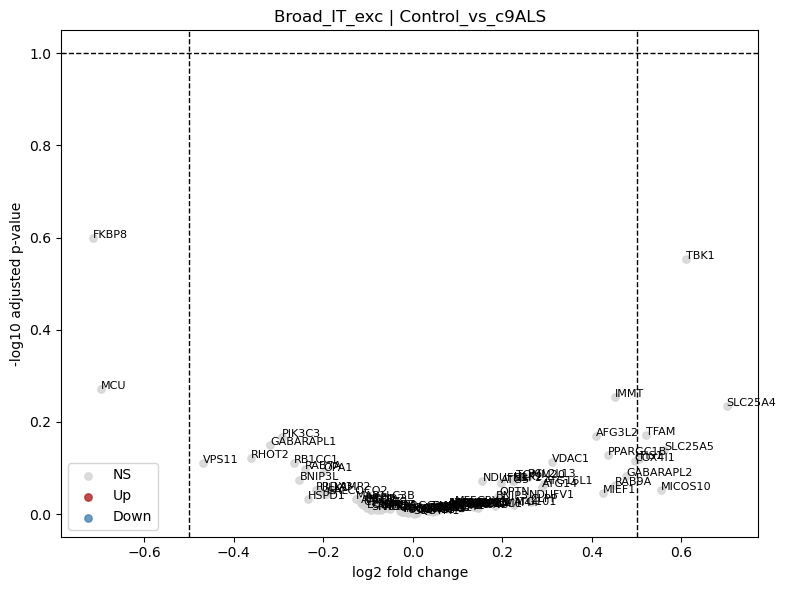

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,analysis_level,group_name,comparison,source_file,neglog10_padj,sig
0,7.306250,0.553157,0.593520,0.931994,0.351340,0.884563,MICOS10,exc_focus,Broad_IT_exc,Control_vs_c9ALS,/Users/wangj/Documents/Computational_Biology/P...,0.053271,NS
1,17.706946,0.136755,0.377650,0.362120,0.717262,0.965601,TFB2M,exc_focus,Broad_IT_exc,Control_vs_c9ALS,/Users/wangj/Documents/Computational_Biology/P...,0.015202,NS
2,343.676702,0.230879,0.204624,1.128306,0.259191,0.834698,TOMM20,exc_focus,Broad_IT_exc,Control_vs_c9ALS,/Users/wangj/Documents/Computational_Biology/P...,0.078470,NS
3,124.687479,0.146600,0.347962,0.421311,0.673528,0.961624,PINK1,exc_focus,Broad_IT_exc,Control_vs_c9ALS,/Users/wangj/Documents/Computational_Biology/P...,0.016995,NS
4,69.374347,0.084486,0.231155,0.365494,0.714743,0.965183,MFN2,exc_focus,Broad_IT_exc,Control_vs_c9ALS,/Users/wangj/Documents/Computational_Biology/P...,0.015390,NS
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,43.625859,-0.103155,0.341188,-0.302342,0.762391,0.971310,LONP1,exc_focus,Broad_IT_exc,Control_vs_c9ALS,/Users/wangj/Documents/Computational_Biology/P...,0.012642,NS
87,185.156976,0.141626,0.280152,0.505531,0.613186,0.950016,GPX4,exc_focus,Broad_IT_exc,Control_vs_c9ALS,/Users/wangj/Documents/Computational_Biology/P...,0.022269,NS
88,21.848544,0.425464,0.497952,0.854427,0.392869,0.900252,MIEF1,exc_focus,Broad_IT_exc,Control_vs_c9ALS,/Users/wangj/Documents/Computational_Biology/P...,0.045636,NS
89,88.785530,0.257241,0.227185,1.132299,0.257509,0.832749,BCL2L13,exc_focus,Broad_IT_exc,Control_vs_c9ALS,/Users/wangj/Documents/Computational_Biology/P...,0.079486,NS


In [ ]:
plot_volcano(
    # analysis_level can be "broad" or "exc_focus".
    analysis_level="exc_focus",
    # group_name can be 
        # broad: "Excitatory_neurons", "Inhibitory_neurons", "Astrocytes", "Microglia", "OPCs".
        # exc_focus: "Projection_like_SCN4B", "Broad_IT_exc".
    group_name="Broad_IT_exc",
    # comparison can be "Control_vs_sALS", "Control_vs_c9ALS", "sALS_vs_c9ALS".
    comparison="Control_vs_c9ALS",
    genes_to_label=autophagy_genes,
)

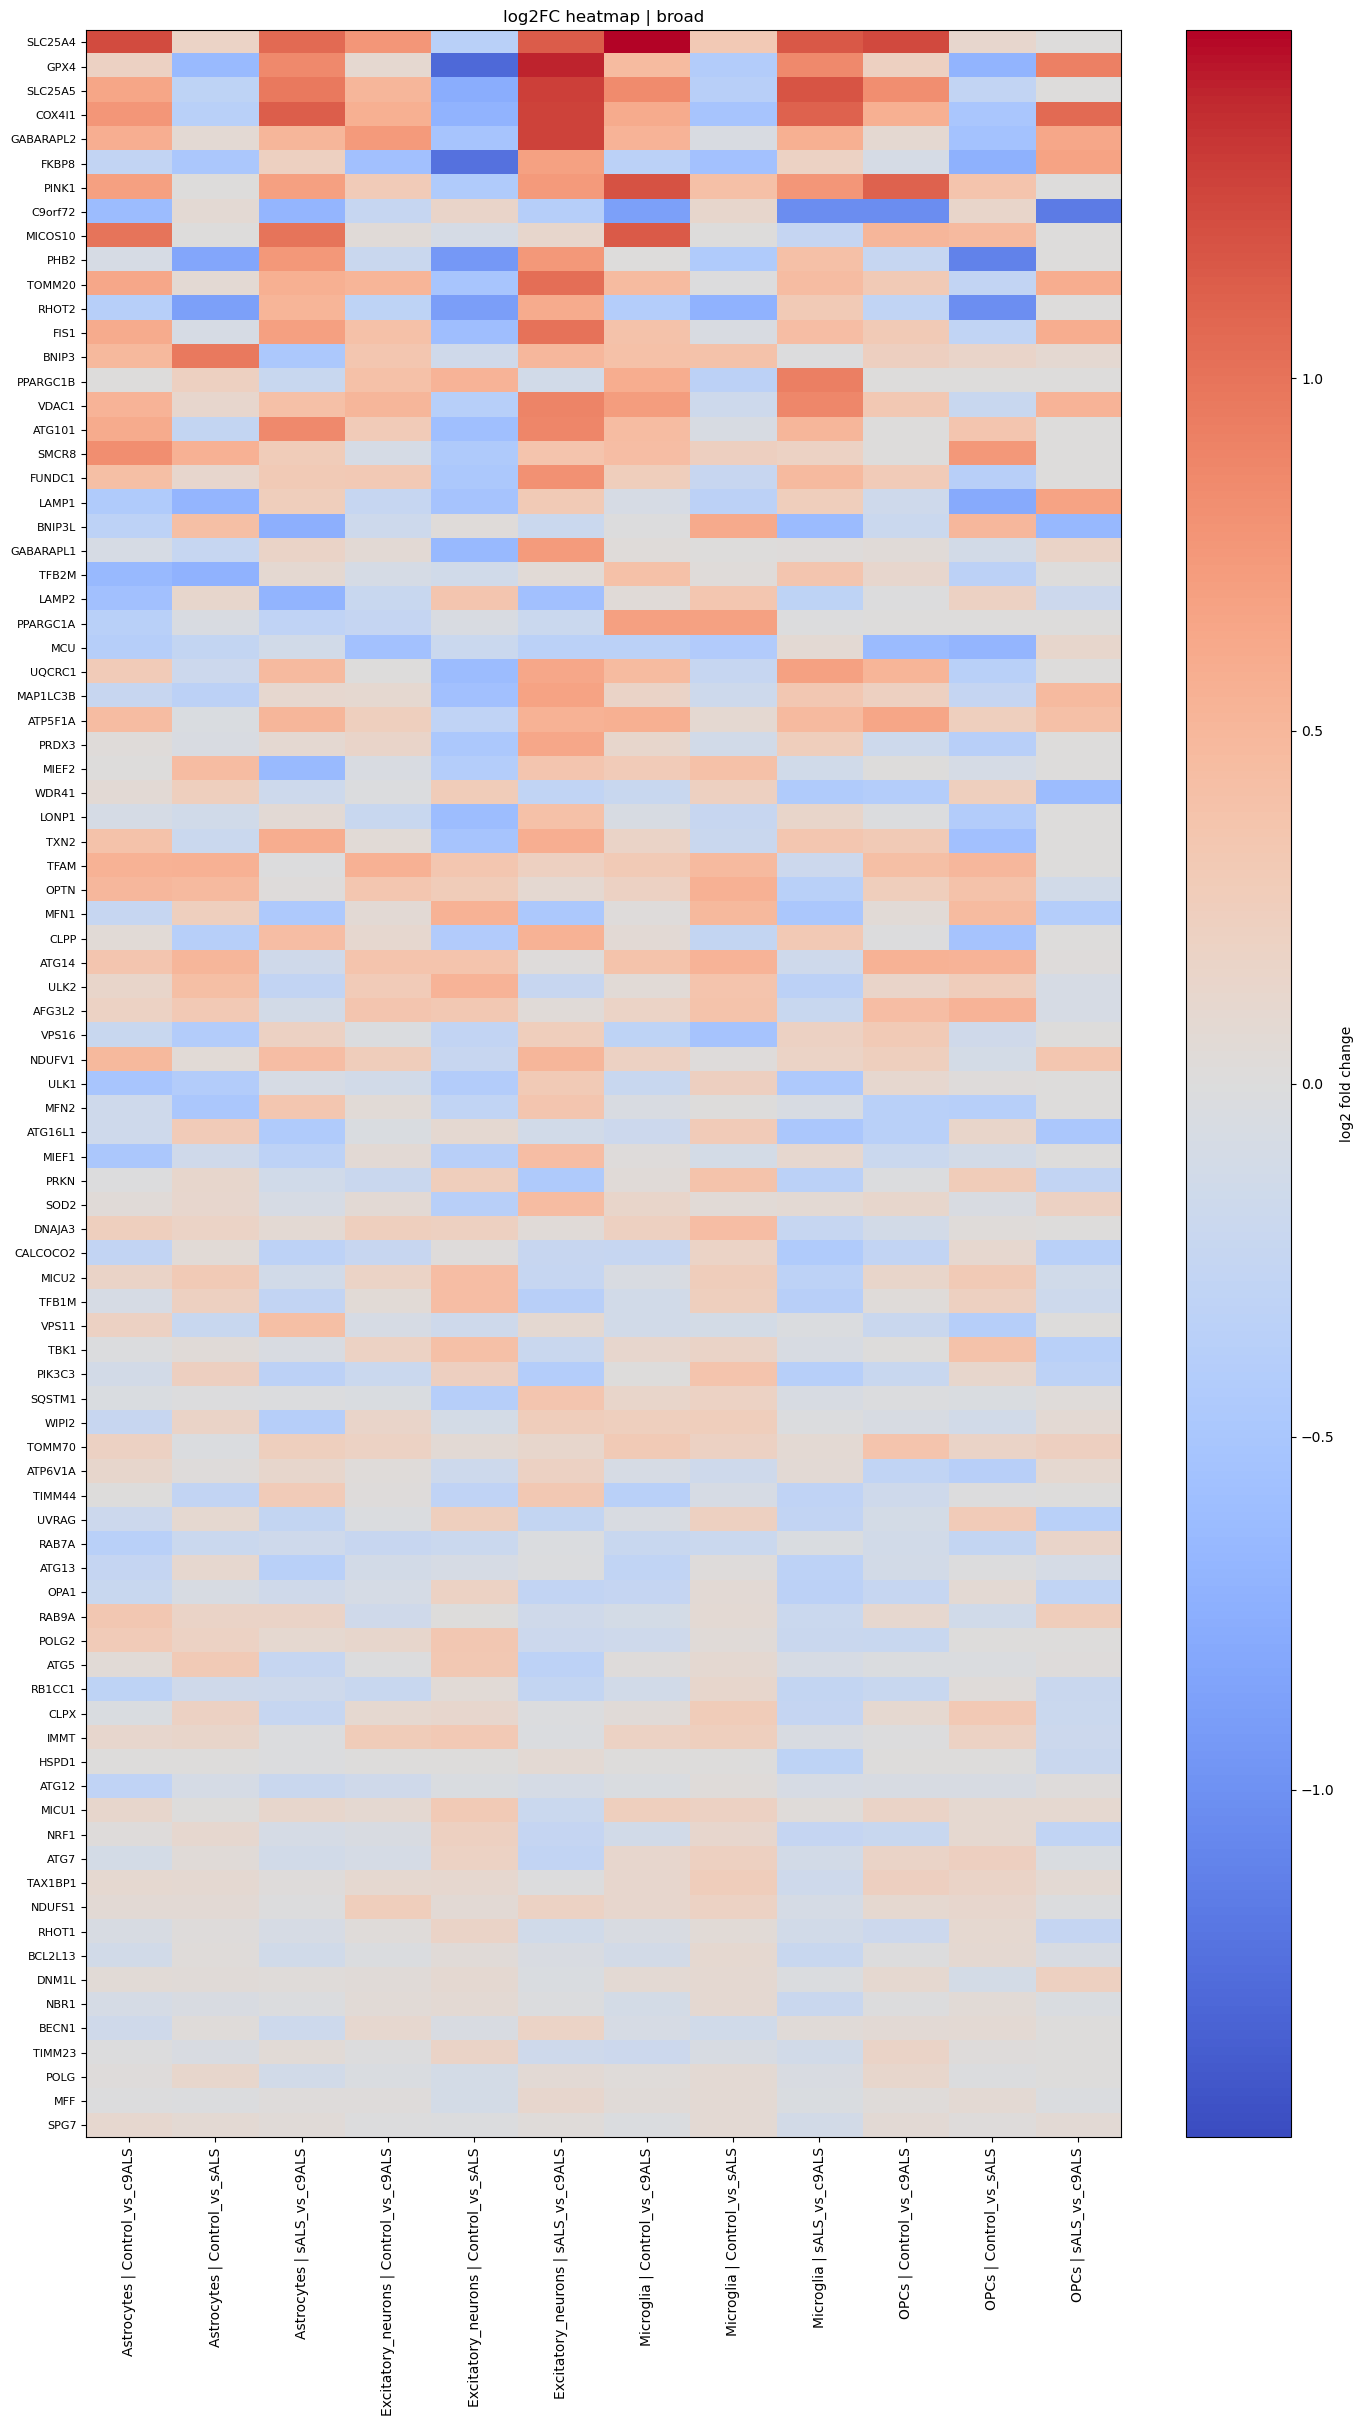

row,Astrocytes | Control_vs_c9ALS,Astrocytes | Control_vs_sALS,Astrocytes | sALS_vs_c9ALS,Excitatory_neurons | Control_vs_c9ALS,Excitatory_neurons | Control_vs_sALS,Excitatory_neurons | sALS_vs_c9ALS,Microglia | Control_vs_c9ALS,Microglia | Control_vs_sALS,Microglia | sALS_vs_c9ALS,OPCs | Control_vs_c9ALS,OPCs | Control_vs_sALS,OPCs | sALS_vs_c9ALS
gene,,,,,,,,,,,,
SLC25A4,1.236103,0.183103,1.060495,0.767798,-0.351231,1.132405,1.492759,0.313178,1.158536,1.242027,0.119307,0.000000
GPX4,0.205350,-0.641203,0.851992,0.101687,-1.292259,1.406391,0.462236,-0.411242,0.857295,0.215321,-0.690895,0.916625
SLC25A5,0.643105,-0.312197,0.957268,0.509343,-0.767827,1.287444,0.840151,-0.369262,1.187645,0.827925,-0.270847,0.000000
COX4I1,0.761029,-0.357854,1.128901,0.563737,-0.701398,1.279619,0.604449,-0.514189,1.102468,0.562275,-0.492068,1.057830
GABARAPL2,0.575559,0.074409,0.508208,0.737036,-0.524249,1.273675,0.534972,-0.048292,0.567698,0.085580,-0.544306,0.638459
...,...,...,...,...,...,...,...,...,...,...,...,...
BECN1,-0.140771,0.027892,-0.163686,0.115070,-0.057801,0.182186,-0.081522,-0.133859,0.039293,0.064824,0.071379,0.000000
TIMM23,-0.009319,-0.051963,0.051969,-0.001259,0.169926,-0.161151,-0.176495,-0.068485,-0.121563,0.166634,0.019104,0.000000
POLG,0.014351,0.138574,-0.117015,-0.043714,-0.098912,0.066919,0.032457,0.073282,-0.053320,0.138660,-0.012652,0.000000


In [150]:
plot_log2fc_heatmap(
    # analysis_level can be "broad" or "exc_focus".
    analysis_level="broad",
    # group_name can be 
        # broad: "Excitatory_neurons", "Inhibitory_neurons", "Astrocytes", "Microglia", "OPCs".
        # exc_focus: "Projection_like_SCN4B", "Broad_IT_exc".
    group_names=["Microglia", "Excitatory_neurons", "Astrocytes", "OPCs"],
    # comparison can be "Control_vs_sALS", "Control_vs_c9ALS", "sALS_vs_c9ALS".
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
    genes=autophagy_genes,
)

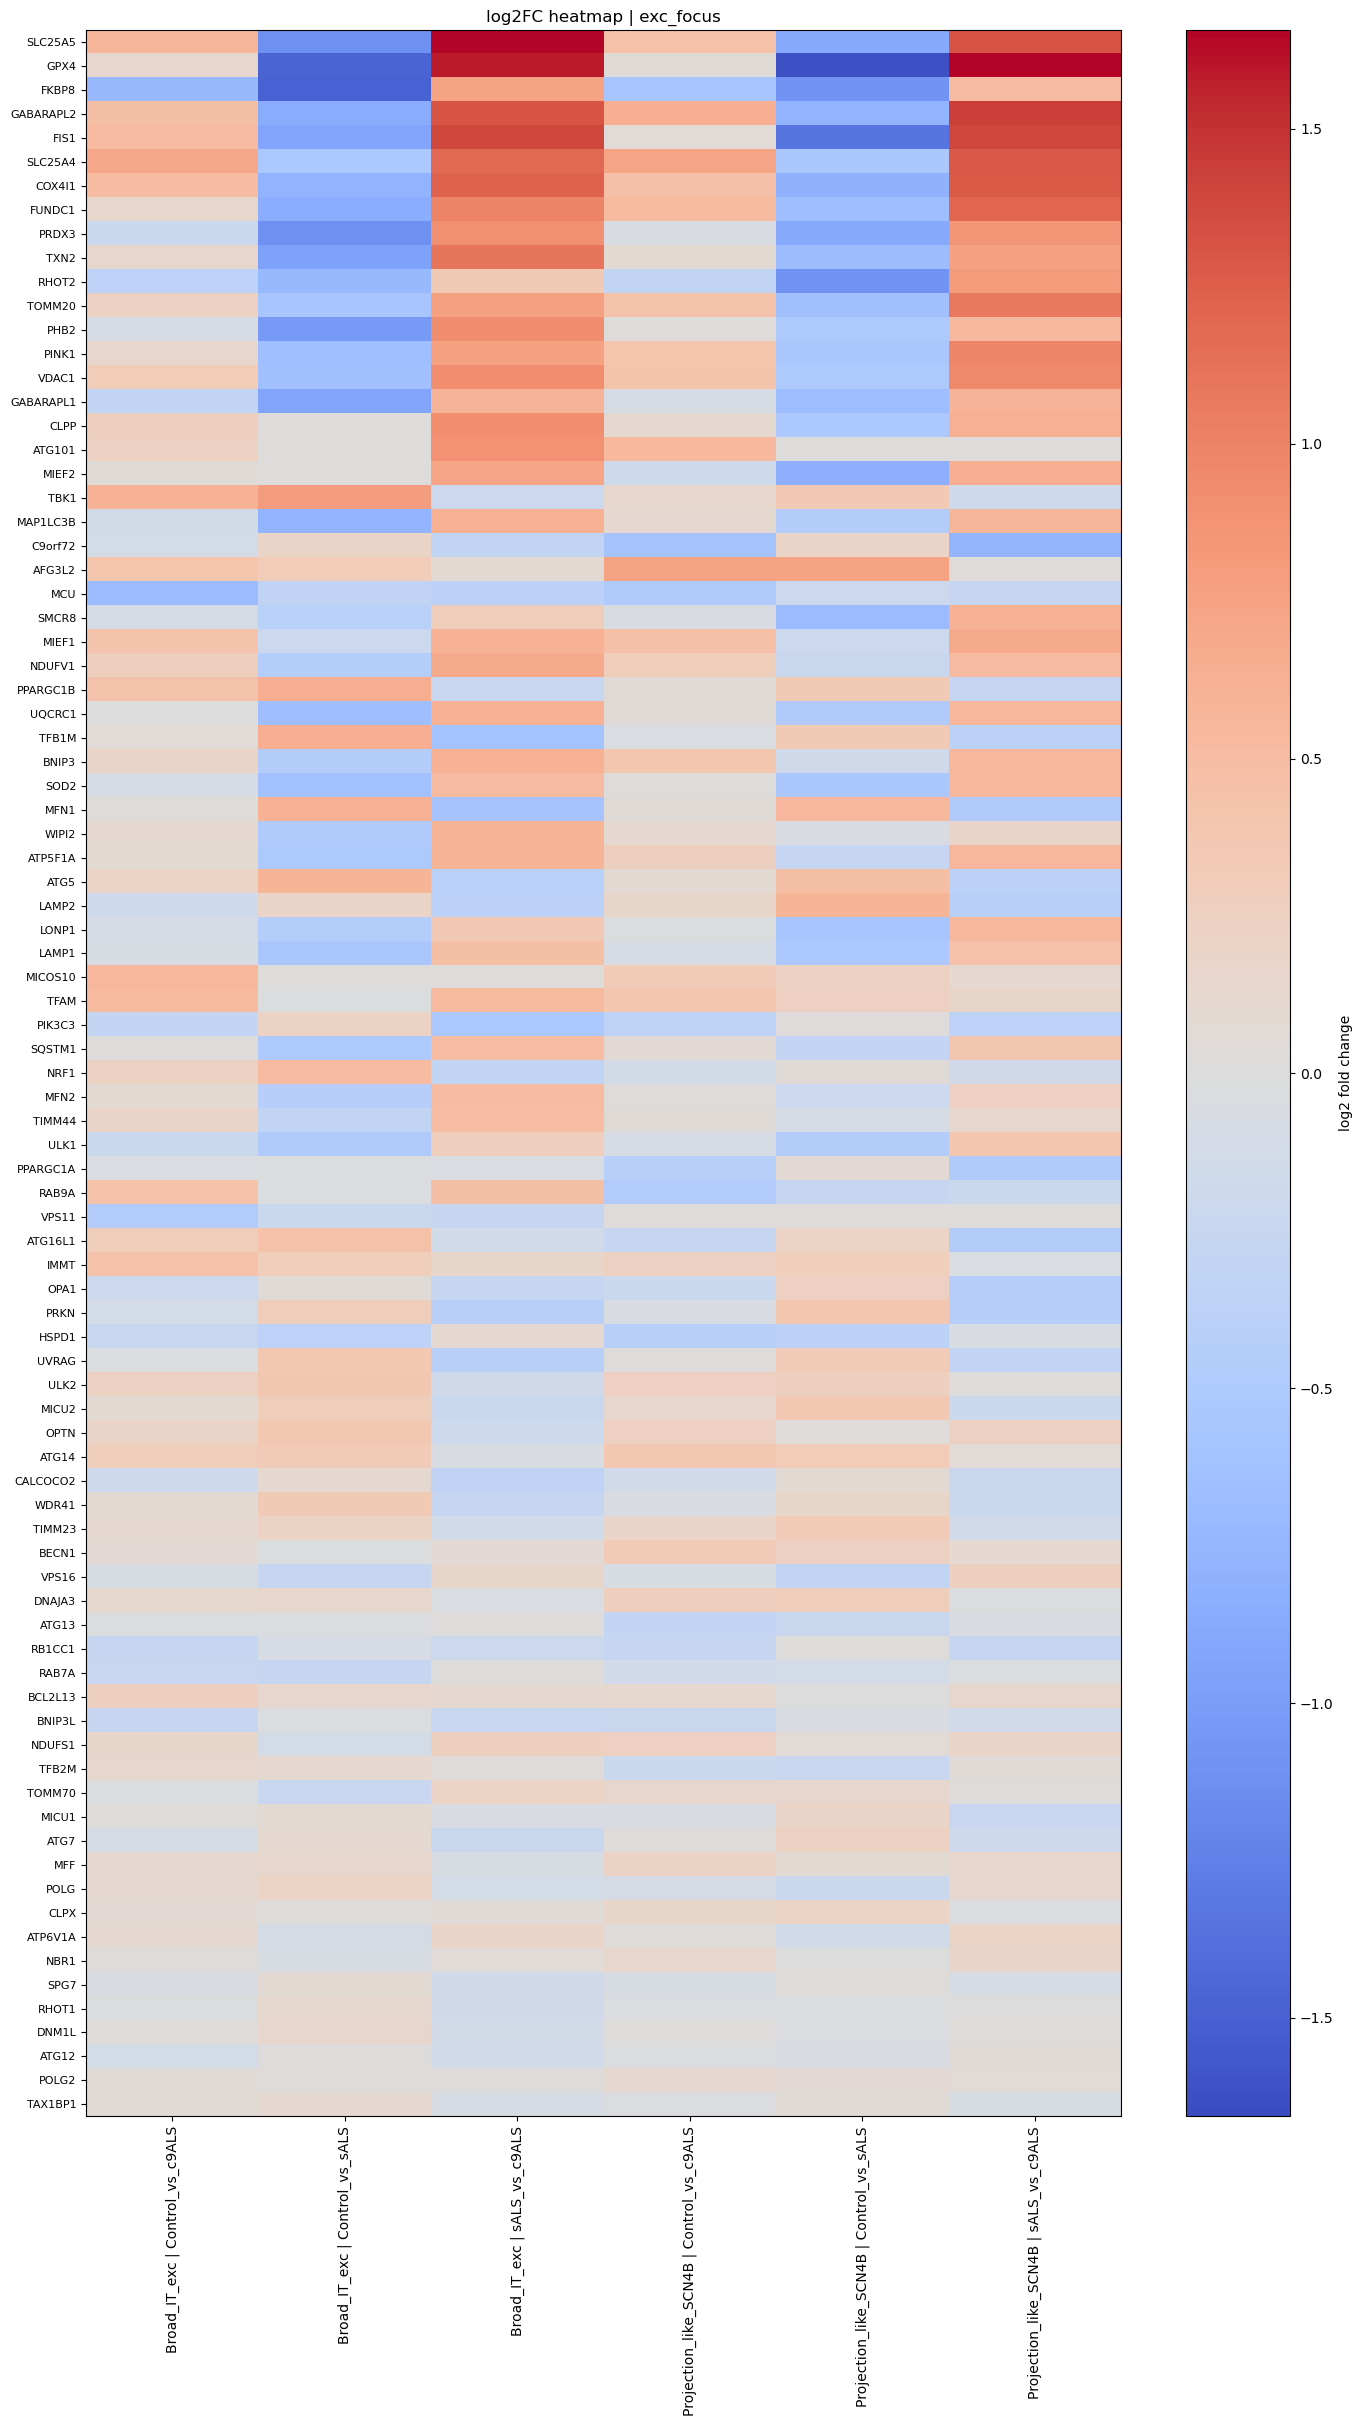

row,Broad_IT_exc | Control_vs_c9ALS,Broad_IT_exc | Control_vs_sALS,Broad_IT_exc | sALS_vs_c9ALS,Projection_like_SCN4B | Control_vs_c9ALS,Projection_like_SCN4B | Control_vs_sALS,Projection_like_SCN4B | sALS_vs_c9ALS
gene,,,,,,
SLC25A5,0.560943,-1.123431,1.656445,0.445328,-0.870007,1.318600
GPX4,0.141626,-1.467409,1.585484,0.043026,-1.605485,1.655011
FKBP8,-0.713534,-1.477976,0.746389,-0.575799,-1.079754,0.515699
GABARAPL2,0.476538,-0.865414,1.312864,0.641117,-0.773168,1.428057
FIS1,0.506177,-0.921586,1.393847,0.060852,-1.335919,1.396534
...,...,...,...,...,...,...
RHOT1,-0.015777,0.125592,-0.158875,-0.032851,-0.014461,-0.011053
DNM1L,0.033053,0.145697,-0.128604,0.001291,-0.027464,0.038445
ATG12,-0.115666,0.004767,-0.139447,-0.021975,-0.059550,0.049426


In [118]:
plot_log2fc_heatmap(
    analysis_level="exc_focus",
    group_names=["Projection_like_SCN4B", "Broad_IT_exc"],
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
    genes=autophagy_genes,
)

In [152]:
summarize_gene(
    gene="SMCR8",
    analysis_level="broad",
    group_names=["Microglia", "Excitatory_neurons", "Astrocytes", "Inhibitory_neurons", "OPCs"],
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
)

,analysis_level,group_name,comparison,gene,log2FoldChange,padj,pvalue,baseMean,source_file
0,broad,Astrocytes,Control_vs_c9ALS,SMCR8,0.817630,0.581101,0.091061,10.018269,/Users/wangj/Documents/Computational_Biology/P...
1,broad,Astrocytes,Control_vs_sALS,SMCR8,0.555101,0.729754,0.243057,12.053796,/Users/wangj/Documents/Computational_Biology/P...
2,broad,Astrocytes,sALS_vs_c9ALS,SMCR8,0.268814,0.869236,0.549756,12.153035,/Users/wangj/Documents/Computational_Biology/P...
3,broad,Excitatory_neurons,Control_vs_c9ALS,SMCR8,-0.090278,0.897074,0.697585,226.951765,/Users/wangj/Documents/Computational_Biology/P...
4,broad,Excitatory_neurons,Control_vs_sALS,SMCR8,-0.450131,0.136034,0.025472,147.919476,/Users/wangj/Documents/Computational_Biology/P...
5,broad,Excitatory_neurons,sALS_vs_c9ALS,SMCR8,0.369114,0.215711,0.084692,180.013219,/Users/wangj/Documents/Computational_Biology/P...
6,broad,Inhibitory_neurons,Control_vs_c9ALS,SMCR8,-0.117441,0.919613,0.679791,56.400188,/Users/wangj/Documents/Computational_Biology/P...
7,broad,Inhibitory_neurons,Control_vs_sALS,SMCR8,-0.510955,0.262587,0.099359,33.831584,/Users/wangj/Documents/Computational_Biology/P...
8,broad,Inhibitory_neurons,sALS_vs_c9ALS,SMCR8,0.391296,0.271607,0.112950,50.564960,/Users/wangj/Documents/Computational_Biology/P...
9,broad,Microglia,Control_vs_c9ALS,SMCR8,0.437041,0.711417,0.208877,28.608380,/Users/wangj/Documents/Computational_Biology/P...


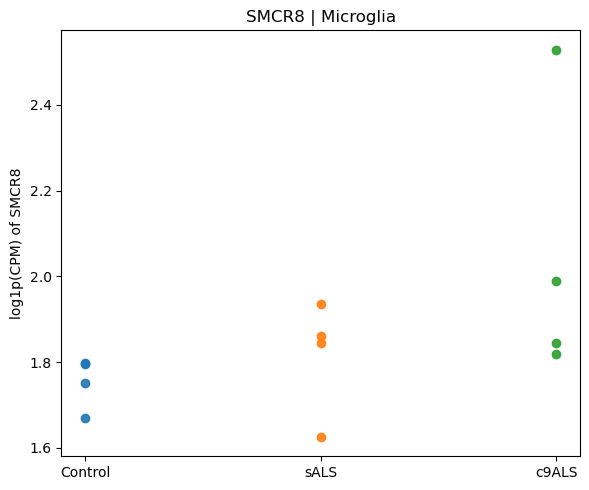

,condition,group_value,groupby_col,n_cells,expr
sample,,,,,
GSM5292143,sALS,Microglia,cell_class_major_harmony,1525,1.935847
GSM5292144,sALS,Microglia,cell_class_major_harmony,3218,1.625336
GSM5292145,sALS,Microglia,cell_class_major_harmony,2066,1.844939
GSM5292146,c9ALS,Microglia,cell_class_major_harmony,2002,2.528501
GSM5292147,c9ALS,Microglia,cell_class_major_harmony,2496,1.843444
GSM5292148,sALS,Microglia,cell_class_major_harmony,3043,1.859829
GSM5292156,c9ALS,Microglia,cell_class_major_harmony,1439,1.819674
GSM5292157,c9ALS,Microglia,cell_class_major_harmony,1677,1.988764
GSM5292174,Control,Microglia,cell_class_major_harmony,1617,1.751746


In [153]:
plot_gene_by_condition(
    adata_merged_pb,
    gene="SMCR8",
    group_value="Microglia",
    groupby_col="cell_class_major_harmony",
)